# Assignment 2: Mastering Big Data Handling

## Dataset: Airbnb Listings Dataset

The original dataset used in this assignment is `airbnb_listings.csv`.
The dataset size is 1846.24 MB and contains 89 columns. Because the dataset is large, different big data handling strategies are applied, including loading fewer columns, chunking, data type optimisation, sampling, and parallel processing using Dask and Polars.

Step 1: Input the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import time
import pandas as pd
import dask.dataframe as dd
import polars as pl

In [ ]:
file_path = "/content/drive/MyDrive/HPDP_A2/airbnb_listings.csv"

In [ ]:
print("File exists:", os.path.exists(file_path))
print("File size:", round(os.path.getsize(file_path) / (1024**2), 2), "MB")

File exists: True
File size: 1846.24 MB


In [ ]:
preview = pd.read_csv(file_path, sep=';', nrows=5)
preview

,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,4008728,https://www.airbnb.com/rooms/4008728,20170402075052,2017-04-02,"Luxurious 3 bedroom, centrum, 180m2",‪This luxurious apartment is situated in the c...,In the heart of hip & lively Amsterdam Centrum...,‪This luxurious apartment is situated in the c...,none,There is a wide variety of cafes and restauran...,...,10,10,9,NaN,Amsterdam,strict,1,1.52,"52.36523660409065, 4.878249575101092","Host Has Profile Pic,Host Identity Verified,Is..."
1,7778612,https://www.airbnb.com/rooms/7778612,20170402075052,2017-04-02,Luxury apartment in city centre,"Beautiful, large (105m2, 2 floors) and quiet a...",1 living room 1 dining room 2 bedrooms 1 bathr...,"Beautiful, large (105m2, 2 floors) and quiet a...",none,Within a few minutes walking you'll be in the ...,...,10,10,9,NaN,Amsterdam,strict,1,0.81,"52.367309030897516, 4.8738407410699915","Host Is Superhost,Host Has Profile Pic,Host Id..."
2,8264596,https://www.airbnb.com/rooms/8264596,20170402075052,2017-04-02,Cosy apartment across Vondelpark,This central located apartment will make you f...,NaN,This central located apartment will make you f...,none,NaN,...,10,10,10,NaN,Amsterdam,flexible,1,0.05,"52.361943953804776, 4.866686522141489","Host Has Profile Pic,Host Identity Verified,Is..."
3,2180729,https://www.airbnb.com/rooms/2180729,20170402075052,2017-04-02,Spacious City Apartment Oud-West,Living like an Amsterdam resident in this ligh...,There are 2 bedrooms each with a double bed. I...,Living like an Amsterdam resident in this ligh...,none,The 85 m2 apartment is located on a quiet stre...,...,9,9,9,NaN,Amsterdam,flexible,1,0.62,"52.37014616115532, 4.866281767968382","Host Has Profile Pic,Host Identity Verified,Is..."
4,14463171,https://www.airbnb.com/rooms/14463171,20170402075052,2017-04-02,Cosy Studio Apartment Center Amsterdam,Studio Apartment Centre Amsterdam Perfect stud...,NaN,Studio Apartment Centre Amsterdam Perfect stud...,none,NaN,...,8,9,9,NaN,Amsterdam,moderate,1,2.04,"52.368817829014425, 4.871249476925455",Host Has Profile Pic


In [ ]:
columns = pd.read_csv(file_path, sep=';', nrows=0).columns

for i, col in enumerate(columns):
    print(i, col)

0 ID
1 Listing Url
2 Scrape ID
3 Last Scraped
4 Name
5 Summary
6 Space
7 Description
8 Experiences Offered
9 Neighborhood Overview
10 Notes
11 Transit
12 Access
13 Interaction
14 House Rules
15 Thumbnail Url
16 Medium Url
17 Picture Url
18 XL Picture Url
19 Host ID
20 Host URL
21 Host Name
22 Host Since
23 Host Location
24 Host About
25 Host Response Time
26 Host Response Rate
27 Host Acceptance Rate
28 Host Thumbnail Url
29 Host Picture Url
30 Host Neighbourhood
31 Host Listings Count
32 Host Total Listings Count
33 Host Verifications
34 Street
35 Neighbourhood
36 Neighbourhood Cleansed
37 Neighbourhood Group Cleansed
38 City
39 State
40 Zipcode
41 Market
42 Smart Location
43 Country Code
44 Country
45 Latitude
46 Longitude
47 Property Type
48 Room Type
49 Accommodates
50 Bathrooms
51 Bedrooms
52 Beds
53 Bed Type
54 Amenities
55 Square Feet
56 Price
57 Weekly Price
58 Monthly Price
59 Security Deposit
60 Cleaning Fee
61 Guests Included
62 Extra People
63 Minimum Nights
64 Maximum Nigh

In [22]:
working_file = "/content/drive/MyDrive/HPDP_A2/airbnb_listings.csv"

In [23]:
print("Working file exists:", os.path.exists(working_file))
print("Working file size:", round(os.path.getsize(working_file) / (1024**2), 2), "MB")

Working file exists: True
Working file size: 1846.24 MB


In [24]:
print("Preview shape:", preview.shape)
print("Number of columns:", len(preview.columns))

for i, col in enumerate(preview.columns):
    print(i, col)

Preview shape: (5, 89)
Number of columns: 89
0 ID
1 Listing Url
2 Scrape ID
3 Last Scraped
4 Name
5 Summary
6 Space
7 Description
8 Experiences Offered
9 Neighborhood Overview
10 Notes
11 Transit
12 Access
13 Interaction
14 House Rules
15 Thumbnail Url
16 Medium Url
17 Picture Url
18 XL Picture Url
19 Host ID
20 Host URL
21 Host Name
22 Host Since
23 Host Location
24 Host About
25 Host Response Time
26 Host Response Rate
27 Host Acceptance Rate
28 Host Thumbnail Url
29 Host Picture Url
30 Host Neighbourhood
31 Host Listings Count
32 Host Total Listings Count
33 Host Verifications
34 Street
35 Neighbourhood
36 Neighbourhood Cleansed
37 Neighbourhood Group Cleansed
38 City
39 State
40 Zipcode
41 Market
42 Smart Location
43 Country Code
44 Country
45 Latitude
46 Longitude
47 Property Type
48 Room Type
49 Accommodates
50 Bathrooms
51 Bedrooms
52 Beds
53 Bed Type
54 Amenities
55 Square Feet
56 Price
57 Weekly Price
58 Monthly Price
59 Security Deposit
60 Cleaning Fee
61 Guests Included
62 E

In [25]:
selected_cols = [
    "ID",
    "Name",
    "Description",
    "Host Since",
    "Host Response Time",
    "City",
    "Country",
    "Latitude",
    "Longitude",
    "Property Type",
    "Room Type",
    "Accommodates",
    "Bathrooms",
    "Bedrooms",
    "Beds",
    "Price",
    "Minimum Nights",
    "Availability 365",
    "Number of Reviews",
    "Review Scores Rating"
]

In [28]:
missing_cols = [col for col in selected_cols if col not in preview.columns]
print("Missing columns:", missing_cols)

Missing columns: []


In [29]:
import time
import pandas as pd

start = time.time()

df_sample = pd.read_csv(
    working_file,
    sep=';',
    usecols=selected_cols,
    nrows=100000
)

end = time.time()

print("Shape:", df_sample.shape)
print("Loading time:", round(end - start, 2), "seconds")
df_sample.head()

Shape: (100000, 20)
Loading time: 7.65 seconds


,ID,Name,Description,Host Since,Host Response Time,City,Country,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Price,Minimum Nights,Availability 365,Number of Reviews,Review Scores Rating
0,4008728,"Luxurious 3 bedroom, centrum, 180m2",‪This luxurious apartment is situated in the c...,2014-09-01,within a day,Amsterdam,Netherlands,52.365237,4.878250,Apartment,Entire home/apt,6.0,1.0,3.0,3.0,600.0,2.0,74.0,31.0,89.0
1,7778612,Luxury apartment in city centre,"Beautiful, large (105m2, 2 floors) and quiet a...",2014-02-05,within a few hours,Amsterdam,Netherlands,52.367309,4.873841,Apartment,Entire home/apt,4.0,1.0,2.0,2.0,175.0,2.0,259.0,15.0,99.0
2,8264596,Cosy apartment across Vondelpark,This central located apartment will make you f...,2014-11-12,NaN,Amsterdam,Netherlands,52.361944,4.866687,Apartment,Entire home/apt,4.0,1.0,2.0,2.0,125.0,4.0,0.0,1.0,100.0
3,2180729,Spacious City Apartment Oud-West,Living like an Amsterdam resident in this ligh...,2013-10-05,within a day,Amsterdam,Netherlands,52.370146,4.866282,Apartment,Entire home/apt,4.0,1.0,2.0,4.0,130.0,3.0,0.0,22.0,97.0
4,14463171,Cosy Studio Apartment Center Amsterdam,Studio Apartment Centre Amsterdam Perfect stud...,2016-08-10,within a day,Amsterdam,Netherlands,52.368818,4.871249,Apartment,Entire home/apt,2.0,1.0,0.0,1.0,80.0,2.0,326.0,16.0,78.0


In [31]:
df_sample.info()

df_sample.isnull().sum().sort_values(ascending=False)

df_sample.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    100000 non-null  int64  
 1   Name                  99919 non-null   object 
 2   Description           99976 non-null   object 
 3   Host Since            99904 non-null   object 
 4   Host Response Time    76945 non-null   object 
 5   City                  99926 non-null   object 
 6   Country               99999 non-null   object 
 7   Latitude              99999 non-null   float64
 8   Longitude             99999 non-null   float64
 9   Property Type         99997 non-null   object 
 10  Room Type             99999 non-null   object 
 11  Accommodates          99987 non-null   float64
 12  Bathrooms             99682 non-null   float64
 13  Bedrooms              99869 non-null   float64
 14  Beds                  99829 non-null   float64
 15  P

,ID,Name,Description,Host Since,Host Response Time,City,Country,Latitude,Longitude,Property Type,Room Type,Accommodates,Bathrooms,Bedrooms,Beds,Price,Minimum Nights,Availability 365,Number of Reviews,Review Scores Rating
count,1.000000e+05,99919,99976,99904,76945,99926,99999,99999.000000,99999.000000,99997,99999,99987.000000,99682.000000,99869.000000,99829.000000,98502.000000,99999.000000,99999.000000,99999.000000,74039.000000
unique,NaN,98787,99134,2911,4,2610,19,NaN,NaN,38,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Studio,"My place is good for couples, solo adventurers...",2015-05-21,within an hour,Paris,United States,NaN,NaN,Apartment,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,14,26,250,40210,10100,27971,NaN,NaN,70445,63418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,9.849273e+06,NaN,NaN,NaN,NaN,NaN,NaN,38.188832,-16.408215,NaN,NaN,3.329713,1.253481,1.384103,1.943033,137.017137,3.508795,167.503675,16.775878,92.944232
std,5.407195e+06,NaN,NaN,NaN,NaN,NaN,NaN,22.629688,70.027569,NaN,NaN,2.111648,0.605834,0.937741,1.502709,147.485003,49.851332,140.462589,32.358551,8.526327
min,6.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,-38.192248,-123.214773,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000
25%,5.343169e+06,NaN,NaN,NaN,NaN,NaN,NaN,38.891439,-73.976198,NaN,NaN,2.000000,1.000000,1.000000,1.000000,55.000000,1.000000,16.000000,1.000000,90.000000
50%,1.005362e+07,NaN,NaN,NaN,NaN,NaN,NaN,41.956825,-0.009768,NaN,NaN,2.000000,1.000000,1.000000,1.000000,90.000000,2.000000,151.000000,4.000000,95.000000
75%,1.459257e+07,NaN,NaN,NaN,NaN,NaN,NaN,51.438288,12.361499,NaN,NaN,4.000000,1.000000,2.000000,2.000000,150.000000,3.000000,315.000000,18.000000,100.000000


Step 2: Define selected columns

In [32]:
selected_cols = [
    "ID",
    "Name",
    "Description",
    "Host Since",
    "Host Response Time",
    "City",
    "Country",
    "Latitude",
    "Longitude",
    "Property Type",
    "Room Type",
    "Accommodates",
    "Bathrooms",
    "Bedrooms",
    "Beds",
    "Price",
    "Minimum Nights",
    "Availability 365",
    "Number of Reviews",
    "Review Scores Rating"
]

Step 3: Create helper functions

In [33]:
import os
import time
import pandas as pd
import dask.dataframe as dd
import polars as pl
import matplotlib.pyplot as plt

working_file = "/content/drive/MyDrive/HPDP_A2/airbnb_listings.csv"

def get_memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024**2)

def clean_price_column(df, col="Price"):
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

In [34]:
print("File exists:", os.path.exists(working_file))
print("File size:", round(os.path.getsize(working_file) / (1024**2), 2), "MB")

File exists: True
File size: 1846.24 MB


Step 4: Dataset description and total row count

In [35]:
chunk_size = 100000
total_rows = 0

start = time.time()

for chunk in pd.read_csv(working_file, sep=';', chunksize=chunk_size):
    total_rows += len(chunk)

end = time.time()

print("Total rows:", total_rows)
print("Total columns:", 89)
print("Execution time:", round(end - start, 2), "seconds")

/tmp/ipykernel_3558/1746688147.py:6: DtypeWarning: Columns (66,82) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(working_file, sep=';', chunksize=chunk_size):
/tmp/ipykernel_3558/1746688147.py:6: DtypeWarning: Columns (0,2,27,66) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(working_file, sep=';', chunksize=chunk_size):
/tmp/ipykernel_3558/1746688147.py:6: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(working_file, sep=';', chunksize=chunk_size):
/tmp/ipykernel_3558/1746688147.py:6: DtypeWarning: Columns (27,37,66) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(working_file, sep=';', chunksize=chunk_size):
/tmp/ipykernel_3558/1746688147.py:6: DtypeWarning: Columns (66) have mixed types. Specify dtype option on import or set low_memory=False.
  

Total rows: 494954
Total columns: 89
Execution time: 48.16 seconds


Step 5: Strategy 1 — Load Less Data

Total rows: 494954
Total columns: 89
Execution time: 48.16 seconds

In [36]:
start = time.time()

df_all_sample = pd.read_csv(
    working_file,
    sep=';',
    nrows=100000
)

end = time.time()

all_columns_time = end - start
all_columns_memory = get_memory_mb(df_all_sample)

print("All columns sample shape:", df_all_sample.shape)
print("All columns memory usage:", round(all_columns_memory, 2), "MB")
print("All columns loading time:", round(all_columns_time, 2), "seconds")

/tmp/ipykernel_3558/1396932560.py:3: DtypeWarning: Columns (66,82) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all_sample = pd.read_csv(


All columns sample shape: (100000, 89)
All columns memory usage: 649.52 MB
All columns loading time: 9.85 seconds


In [37]:
start = time.time()

df_less_sample = pd.read_csv(
    working_file,
    sep=';',
    usecols=selected_cols,
    nrows=100000
)

end = time.time()

less_columns_time = end - start
less_columns_memory = get_memory_mb(df_less_sample)

print("Selected columns sample shape:", df_less_sample.shape)
print("Selected columns memory usage:", round(less_columns_memory, 2), "MB")
print("Selected columns loading time:", round(less_columns_time, 2), "seconds")

Selected columns sample shape: (100000, 20)
Selected columns memory usage: 138.69 MB
Selected columns loading time: 4.81 seconds


In [38]:
memory_saved = all_columns_memory - less_columns_memory
memory_reduction = (memory_saved / all_columns_memory) * 100

print("Memory saved:", round(memory_saved, 2), "MB")
print("Memory reduction:", round(memory_reduction, 2), "%")

Memory saved: 510.83 MB
Memory reduction: 78.65 %


Step 6: Strategy 2 — Chunking

In [39]:
chunk_size = 100000

room_review_sum = {}
room_count = {}

start = time.time()

for chunk in pd.read_csv(
    working_file,
    sep=';',
    usecols=["Room Type", "Number of Reviews"],
    chunksize=chunk_size
):
    chunk["Number of Reviews"] = pd.to_numeric(
        chunk["Number of Reviews"],
        errors="coerce"
    )

    grouped = chunk.groupby("Room Type")["Number of Reviews"].agg(["sum", "count"])

    for room_type, row in grouped.iterrows():
        room_review_sum[room_type] = room_review_sum.get(room_type, 0) + row["sum"]
        room_count[room_type] = room_count.get(room_type, 0) + row["count"]

end = time.time()

chunking_time = end - start

chunk_result = {
    room_type: room_review_sum[room_type] / room_count[room_type]
    for room_type in room_review_sum
}

print("Average number of reviews by room type:")
print(chunk_result)
print("Chunking execution time:", round(chunking_time, 2), "seconds")

Average number of reviews by room type:
{'Entire home/apt': np.float64(17.186313980880247), 'Private room': np.float64(16.22202360916045), 'Shared room': np.float64(11.108401387179773), '9': np.float64(nan)}
Chunking execution time: 25.82 seconds


/tmp/ipykernel_3558/3264388233.py:30: RuntimeWarning: invalid value encountered in scalar divide
  room_type: room_review_sum[room_type] / room_count[room_type]


Step 7: Strategy 3 — Data Type Optimisation

In [40]:
df_opt = pd.read_csv(
    working_file,
    sep=';',
    usecols=selected_cols,
    nrows=100000
)

before_opt_memory = get_memory_mb(df_opt)

print("Before optimisation memory:", round(before_opt_memory, 2), "MB")
print(df_opt.dtypes)

Before optimisation memory: 138.69 MB
ID                        int64
Name                     object
Description              object
Host Since               object
Host Response Time       object
City                     object
Country                  object
Latitude                float64
Longitude               float64
Property Type            object
Room Type                object
Accommodates            float64
Bathrooms               float64
Bedrooms                float64
Beds                    float64
Price                   float64
Minimum Nights          float64
Availability 365        float64
Number of Reviews       float64
Review Scores Rating    float64
dtype: object


In [41]:
df_opt = clean_price_column(df_opt)

In [42]:
category_cols = [
    "Name",
    "Host Response Time",
    "City",
    "Country",
    "Property Type",
    "Room Type"
]

for col in category_cols:
    if col in df_opt.columns:
        df_opt[col] = df_opt[col].astype("category")

In [43]:
integer_cols = [
    "ID",
    "Accommodates",
    "Minimum Nights",
    "Availability 365",
    "Number of Reviews"
]

float_cols = [
    "Latitude",
    "Longitude",
    "Bathrooms",
    "Bedrooms",
    "Beds",
    "Price",
    "Review Scores Rating"
]

for col in integer_cols:
    if col in df_opt.columns:
        df_opt[col] = pd.to_numeric(df_opt[col], errors="coerce", downcast="integer")

for col in float_cols:
    if col in df_opt.columns:
        df_opt[col] = pd.to_numeric(df_opt[col], errors="coerce", downcast="float")

In [44]:
after_opt_memory = get_memory_mb(df_opt)
opt_memory_saved = before_opt_memory - after_opt_memory
opt_reduction = (opt_memory_saved / before_opt_memory) * 100

print("Before optimisation:", round(before_opt_memory, 2), "MB")
print("After optimisation:", round(after_opt_memory, 2), "MB")
print("Memory saved:", round(opt_memory_saved, 2), "MB")
print("Reduction percentage:", round(opt_reduction, 2), "%")

print(df_opt.dtypes)

Before optimisation: 138.69 MB
After optimisation: 110.82 MB
Memory saved: 27.87 MB
Reduction percentage: 20.09 %
ID                         int32
Name                    category
Description               object
Host Since                object
Host Response Time      category
City                    category
Country                 category
Latitude                 float32
Longitude                float32
Property Type           category
Room Type               category
Accommodates             float64
Bathrooms                float32
Bedrooms                 float32
Beds                     float32
Price                    float32
Minimum Nights           float64
Availability 365         float64
Number of Reviews        float64
Review Scores Rating     float32
dtype: object


Step 8: Strategy 4 — Sampling

In [45]:
start = time.time()

df_sample_base = pd.read_csv(
    working_file,
    sep=';',
    usecols=selected_cols,
    nrows=300000
)

sample_df = df_sample_base.sample(frac=0.1, random_state=42)

end = time.time()

sampling_time = end - start

print("Original sample shape:", df_sample_base.shape)
print("10% sampled shape:", sample_df.shape)
print("Sampling execution time:", round(sampling_time, 2), "seconds")

/tmp/ipykernel_3558/1047572603.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sample_base = pd.read_csv(


Original sample shape: (300000, 20)
10% sampled shape: (30000, 20)
Sampling execution time: 17.25 seconds


In [46]:
sample_df = clean_price_column(sample_df)

sample_price_result = sample_df.groupby("Room Type")["Price"].mean()

sample_price_result

,Price
Room Type,
Entire home/apt,173.172152
Private room,77.623273
Shared room,63.626118


Step 9: Strategy 5 — Dask parallel processing

In [48]:
import dask.dataframe as dd
import time

dask_cols = ["Room Type", "Number of Reviews"]

start = time.time()

ddf = dd.read_csv(
    working_file,
    sep=';',
    usecols=dask_cols,
    assume_missing=True,
    on_bad_lines='skip',
    blocksize=None
)

dask_result = ddf.groupby("Room Type")["Number of Reviews"].mean().compute()

end = time.time()

dask_time = end - start

print(dask_result)
print("Dask execution time:", round(dask_time, 2), "seconds")

Room Type
9                        NaN
Entire home/apt    17.186314
Private room       16.222024
Shared room        11.108401
<NA>                     NaN
Name: Number of Reviews, dtype: float64
Dask execution time: 33.84 seconds


Step 10: Strategy 5 — Polars processing

In [49]:
import polars as pl
import time

start = time.time()

polars_result = (
    pl.scan_csv(
        working_file,
        separator=';'
    )
    .select(selected_cols)
    .group_by("Room Type")
    .agg(
        pl.col("Number of Reviews").mean().alias("Average Number of Reviews")
    )
    .collect()
)

end = time.time()

polars_time = end - start

print(polars_result)
print("Polars execution time:", round(polars_time, 2), "seconds")

shape: (5, 2)
┌─────────────────┬───────────────────────────┐
│ Room Type       ┆ Average Number of Reviews │
│ ---             ┆ ---                       │
│ str             ┆ f64                       │
╞═════════════════╪═══════════════════════════╡
│ null            ┆ null                      │
│ 9               ┆ null                      │
│ Entire home/apt ┆ 17.186314                 │
│ Private room    ┆ 16.222024                 │
│ Shared room     ┆ 11.108401                 │
└─────────────────┴───────────────────────────┘
Polars execution time: 6.09 seconds


Step 11: Pandas baseline for comparison

In [50]:
start = time.time()

df_pandas_compare = pd.read_csv(
    working_file,
    sep=';',
    usecols=["Room Type", "Number of Reviews"]
)

pandas_result = df_pandas_compare.groupby("Room Type")["Number of Reviews"].mean()

end = time.time()

pandas_compare_time = end - start
pandas_compare_memory = get_memory_mb(df_pandas_compare)

print(pandas_result)
print("Pandas execution time:", round(pandas_compare_time, 2), "seconds")
print("Pandas memory usage:", round(pandas_compare_memory, 2), "MB")

Room Type
9                        NaN
Entire home/apt    17.186314
Private room       16.222024
Shared room        11.108401
Name: Number of Reviews, dtype: float64
Pandas execution time: 26.95 seconds
Pandas memory usage: 33.46 MB


Step 12: Create final comparison table

In [51]:
comparison_df = pd.DataFrame({
    "Method": [
        "Pandas - All Columns Sample",
        "Pandas - Selected Columns Sample",
        "Pandas - Chunking",
        "Pandas - Data Type Optimisation",
        "Pandas - Sampling",
        "Pandas - Baseline GroupBy",
        "Dask - GroupBy",
        "Polars - Lazy GroupBy"
    ],
    "Dataset Used": [
        "100,000 rows × 89 columns",
        "100,000 rows × 20 columns",
        "Full dataset in chunks",
        "100,000 rows × 20 columns",
        "300,000 rows then 10% sample",
        "Full dataset, 2 columns",
        "Full dataset, 20 columns",
        "Full dataset, 20 columns"
    ],
    "Memory Usage MB": [
        round(all_columns_memory, 2),
        round(less_columns_memory, 2),
        "Low - chunk based",
        round(after_opt_memory, 2),
        round(get_memory_mb(sample_df), 2),
        round(pandas_compare_memory, 2),
        "Partitioned / lazy",
        "Lazy execution"
    ],
    "Execution Time Seconds": [
        round(all_columns_time, 2),
        round(less_columns_time, 2),
        round(chunking_time, 2),
        "N/A",
        round(sampling_time, 2),
        round(pandas_compare_time, 2),
        round(dask_time, 2),
        round(polars_time, 2)
    ],
    "Purpose": [
        "Baseline full-column loading",
        "Load less data",
        "Process large file safely",
        "Reduce memory usage",
        "Fast prototyping",
        "Traditional Pandas comparison",
        "Parallel processing",
        "Fast lazy processing"
    ]
})

comparison_df

,Method,Dataset Used,Memory Usage MB,Execution Time Seconds,Purpose
0,Pandas - All Columns Sample,"100,000 rows × 89 columns",649.52,9.85,Baseline full-column loading
1,Pandas - Selected Columns Sample,"100,000 rows × 20 columns",138.69,4.81,Load less data
2,Pandas - Chunking,Full dataset in chunks,Low - chunk based,25.82,Process large file safely
3,Pandas - Data Type Optimisation,"100,000 rows × 20 columns",110.82,N/A,Reduce memory usage
4,Pandas - Sampling,"300,000 rows then 10% sample",42.72,17.25,Fast prototyping
5,Pandas - Baseline GroupBy,"Full dataset, 2 columns",33.46,26.95,Traditional Pandas comparison
6,Dask - GroupBy,"Full dataset, 20 columns",Partitioned / lazy,33.84,Parallel processing
7,Polars - Lazy GroupBy,"Full dataset, 20 columns",Lazy execution,6.09,Fast lazy processing


Step 13: Create charts

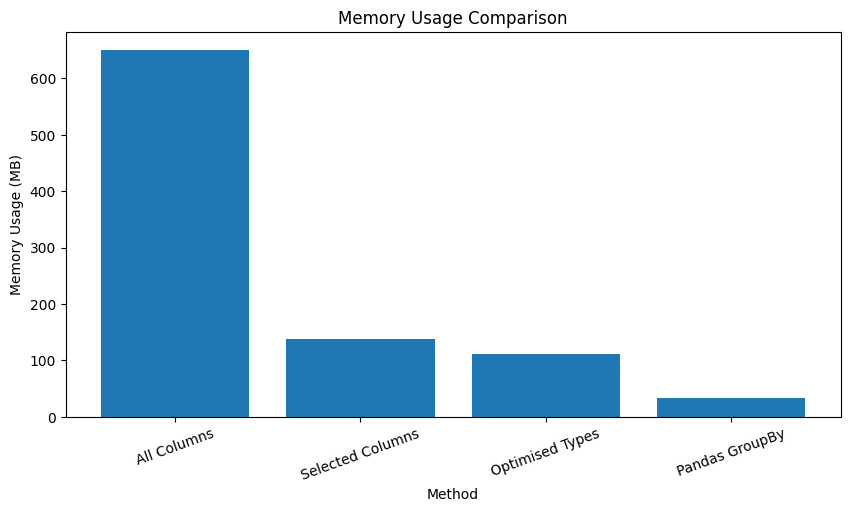

In [52]:
memory_chart = pd.DataFrame({
    "Method": [
        "All Columns",
        "Selected Columns",
        "Optimised Types",
        "Pandas GroupBy"
    ],
    "Memory Usage MB": [
        all_columns_memory,
        less_columns_memory,
        after_opt_memory,
        pandas_compare_memory
    ]
})

plt.figure(figsize=(10, 5))
plt.bar(memory_chart["Method"], memory_chart["Memory Usage MB"])
plt.title("Memory Usage Comparison")
plt.xlabel("Method")
plt.ylabel("Memory Usage (MB)")
plt.xticks(rotation=20)
plt.show()

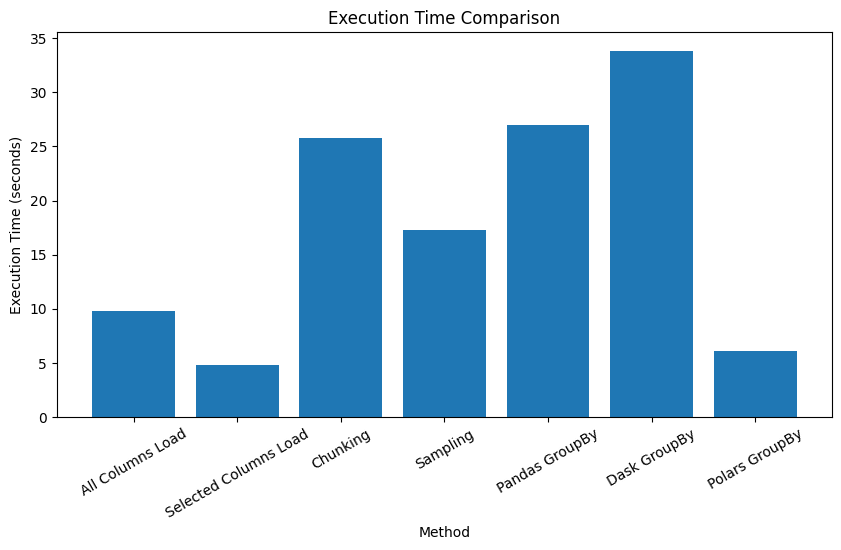

In [53]:
time_chart = pd.DataFrame({
    "Method": [
        "All Columns Load",
        "Selected Columns Load",
        "Chunking",
        "Sampling",
        "Pandas GroupBy",
        "Dask GroupBy",
        "Polars GroupBy"
    ],
    "Execution Time Seconds": [
        all_columns_time,
        less_columns_time,
        chunking_time,
        sampling_time,
        pandas_compare_time,
        dask_time,
        polars_time
    ]
})

plt.figure(figsize=(10, 5))
plt.bar(time_chart["Method"], time_chart["Execution Time Seconds"])
plt.title("Execution Time Comparison")
plt.xlabel("Method")
plt.ylabel("Execution Time (seconds)")
plt.xticks(rotation=30)
plt.show()